In [1]:
import os
import sys
import gc

In [2]:
XMem_path = os.path.abspath("../../../external/XMem")  # Parent folder /app/mount
sys.path.append(XMem_path)
# !wget -P ./saves/ https://github.com/hkchengrex/XMem/releases/download/v1.0/XMem.pth

In [3]:
from inspect import getsource
from pathlib import Path
from os import path

import cv2
import numpy as np
from PIL import Image
from skimage import io
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchmetrics.classification import BinaryJaccardIndex, MulticlassJaccardIndex
from torchmetrics.classification import Dice

# from inference.data.test_datasets import LongTestDataset, DAVISTestDataset, YouTubeVOSTestDataset
# from inference.data.mask_mapper import MaskMapper
from model.network import XMem
from inference.inference_core import InferenceCore
from inference.data.mask_mapper import MaskMapper

from inference.interact.interactive_utils import (
    image_to_torch,
    index_numpy_to_one_hot_torch,
    torch_prob_to_numpy_mask,
    overlay_davis,
)

# from progressbar import progressbar

torch.set_grad_enabled(False)

# default configuration
config = {
    "top_k": 30,
    "mem_every": 5,
    "deep_update_every": -1,
    "enable_long_term": True,
    "enable_long_term_count_usage": True,
    "num_prototypes": 128,
    "min_mid_term_frames": 5,
    "max_mid_term_frames": 10,
    "max_long_term_elements": 10000,
}

if torch.cuda.is_available():
    print("Using GPU")
    device = "cuda"
else:
    print("CUDA not available. Please connect to a GPU instance if possible.")
    device = "cpu"

# network = XMem(config, '../XMem/saves/XMem.pth').eval().to(device)

Using GPU


In [4]:
!nvidia-smi

Sun Oct 13 15:48:12 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A10                     Off |   00000000:03:00.0 Off |                    0 |
|  0%   56C    P0             38W /  150W |     288MiB /  23028MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
torch.cuda.empty_cache()

COLOR = (3, 192, 60)

NUM_OBJECTS = 1  # Binary Segmentation
NUM_OBJECTS = 30  # Multi Class Segmentation

main_folder = Path("../../../data/endovis/endo17/data")

endo17_frames = main_folder / "frames" / "endo17_test_frames"
endo17_masks = main_folder / "masks" / "endo17_test_masks" / "part_masks"

In [6]:
def binary2color(binary_mask, color):
    binary_mask = torch_prob_to_numpy_mask(binary_mask)
    pred_mask = np.tile(binary_mask[..., np.newaxis], (1, 1, 3))  # Make it 3 Channel
    mask = np.where(pred_mask == (1,) * 3, color, 0).astype(
        "uint8"
    )  # Convert Prediction with Color
    return mask

In [7]:
def overlaymask(frames_dict, pred_dict, color=None):
    overlay_frames = {}
    for frame_name, mask in pred_dict.items():
        frame = frames_dict[frame_name]
        # frame = cv2.addWeighted(frame, 1.0, mask, 0.5, 0)
        mask = torch_prob_to_numpy_mask(mask)
        frame = overlay_davis(frame, mask)
        overlay_frames[frame_name] = frame
    return overlay_frames

In [8]:
def frames2video(frames_dict, folder_save_path, video_name, FPS=5):
    frame = frames_dict[list(frames_dict.keys())[-1]]
    size1, size2, _ = frame.shape
    out = cv2.VideoWriter(
        f"{folder_save_path}/{video_name}_{FPS}FPS.mp4",
        cv2.VideoWriter_fourcc(*"mp4v"),
        FPS,
        (size2, size1),
        True,
    )
    # Sorting the frames according to frame number eg: frame_007.png
    for _, i in sorted(frames_dict.items(), key=lambda x: x[0]):
        out_img = cv2.cvtColor(i, cv2.COLOR_BGR2RGB)
        out.write(out_img)
    out.release()

In [9]:
def multiclassIoU(mask, truth_mask, IoU=None):
    metric = BinaryJaccardIndex()
    IoU = {i: [] for i in range(1, NUM_OBJECTS + 1)} if IoU is None else IoU
    for i in set(np.unique(mask)).union(set(np.unique(truth_mask))):
        if i == 0:
            continue
        IoU[i].append(
            metric(
                torch.tensor(np.where(mask == i, 1, 0)),
                torch.tensor(np.where(truth_mask == i, 1, 0)),
            ).item()
        )
    return IoU

In [10]:
def getIoU(pred_frames, gt_path):
    metric = BinaryJaccardIndex()
    dice_metric = Dice()

    IoU = {i: [] for i in range(1, NUM_OBJECTS + 1)}
    instrumentsPresent = {}
    dice = []

    for frame_name, mask in pred_frames.items():
        mask = torch_prob_to_numpy_mask(mask)
        try:
            truth_mask = io.imread(gt_path / frame_name)
        except FileNotFoundError:
            continue
        truth_mask = np.where(truth_mask == 8, 0, truth_mask)
        if np.sum(truth_mask) == 0:
            continue
        for i in np.unique(truth_mask):
            if i != 0:
                instrumentsPresent[i] = instrumentsPresent.get(i, 0) + 1
        IoU = multiclassIoU(mask, truth_mask, IoU)

    return IoU, instrumentsPresent

In [11]:
im_normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)


def resize_mask(mask, size):
    mask = mask.unsqueeze(0).unsqueeze(0)
    h, w = mask.shape[-2:]
    min_hw = min(h, w)
    return F.interpolate(
        mask, (int(h / min_hw * size), int(w / min_hw * size)), mode="nearest"
    )[0]


def singleVideoInference(images_paths, first_mask, processor, size=-1):
    predictions = {}
    frames = {}
    with torch.cuda.amp.autocast(enabled=True):

        images_paths = sorted(images_paths)

        # First Frame
        frame = io.imread(images_paths[0])
        shape = frame.shape[:2]
        if size < 0:
            im_transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    im_normalization,
                ]
            )
        else:
            im_transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    im_normalization,
                    transforms.Resize(size, interpolation=InterpolationMode.BILINEAR),
                ]
            )

        frame_torch = im_transform(frame).to(device)
        first_mask = first_mask.astype(np.uint8)
        if size > 0:
            first_mask = torch.tensor(first_mask).to(device)
            first_mask = resize_mask(first_mask, size)
            # Convert HxW to NxHxW. Taking [1:], since [0] is Background Mask
            first_mask = index_numpy_to_one_hot_torch(
                first_mask[0].cpu().numpy(), NUM_OBJECTS + 1
            ).to(device)[1:]
        else:
            first_mask = index_numpy_to_one_hot_torch(first_mask, NUM_OBJECTS + 1).to(
                device
            )
            first_mask = first_mask[1:]

        prediction = processor.step(frame_torch, first_mask)

        for image_path in tqdm(images_paths[1:]):
            frame = io.imread(image_path)
            # convert numpy array to pytorch tensor format
            frame_torch = im_transform(frame).to(device)

            prediction = processor.step(frame_torch)
            # Upsample to original size if needed
            if size > 0:
                prediction = F.interpolate(
                    prediction.unsqueeze(1), shape, mode="bilinear", align_corners=False
                )[:, 0]
            predictions[image_path.name] = prediction
            frames[image_path.name] = frame

    return frames, predictions

In [12]:
def firstMaskGT(image_files, mask_folder):
    image_files = sorted(image_files)
    idx = 0
    for image_path in image_files:

        if "png" not in image_path.name:
            continue

        # Getting the Path to Mask Ground Truth using RGB Image path
        mask_path = mask_folder / image_path.parent.name / image_path.name

        mask = io.imread(mask_path)
        # All 255 Values replaced with 1, other values remain as it is.
        mask = np.where(mask == 8, 0, mask)

        if np.sum(mask) > 0:
            return mask, idx

        idx += 1

    return None, -1

In [13]:
def doInference(
    network_path,
    config,
    frames_folder,
    mask_folder,
    subset=None,
    pred_mask_folder=None,
    size=-1,
):
    overallIoU = {i: [] for i in range(1, NUM_OBJECTS + 1)}
    superIoU = []
    for video_folder in sorted(frames_folder.iterdir()):

        if subset is not None and video_folder.name not in subset:
            continue

        # Clearing GPU Cache
        torch.cuda.empty_cache()
        network = XMem(config, network_path).eval().to(device)
        processor = InferenceCore(network, config=config)
        processor.set_all_labels(range(1, NUM_OBJECTS + 1))

        # All Images
        image_files = sorted([i for i in video_folder.iterdir() if "png" in i.name])
        if pred_mask_folder:
            mask_path = [
                i for i in pred_mask_folder.iterdir() if video_folder.name in i.name
            ][0]
            mask = io.imread(mask_path)
            # All 0 pixel is 0, everything else(which is mask) is 1
            mask = np.where(mask == 0, 0, 1)
            # seq_01_0.png -> Two Splits, one on '_', other on '.'
            start_idx = int((mask_path.name.split("_")[-1]).split(".")[0])
        else:  # Ground Truth
            mask, start_idx = firstMaskGT(image_files, mask_folder)

        print(f"Running Inference on {video_folder.name}...")
        frames, predictions = singleVideoInference(
            image_files[start_idx:], mask, processor, size=size
        )
        IoU, instrumentsPresent = getIoU(predictions, mask_folder / video_folder.name)

        print(
            f'Video "{video_folder.name}" Instruments Present are {instrumentsPresent}, the IoUs are:'
        )
        for k, IoUList in IoU.items():
            if len(IoUList) == 0:
                continue
            print(f"Instrument: {k}, meanIoU is {sum(IoUList)/len(IoUList)}")
            overallIoU[k].extend(IoUList)
        print()

        # frames2video(overlaymask(frames, predictions), Path("./"), video_folder.name, FPS=1)

        del network, processor
        torch.cuda.empty_cache()
        gc.collect()
        torch.cuda.empty_cache()

    print(f"Average IoU over all videos is:")
    for k, IoUList in overallIoU.items():
        if len(IoUList) == 0:
            print(f"Instrument: {k}, meanIoU is 0.0")
            superIoU.append(0)
            continue
        superIoU.append(sum(IoUList) / len(IoUList))
        print(f"Instrument: {k}, meanIoU is {sum(IoUList)/len(IoUList)}")

    print(
        f"meanIoU over all the Instrument over all the videos is {sum(superIoU)/len(superIoU)}"
    )

    return overallIoU

In [14]:
# only running for videos with less than 100 frames
test_subset = ["", "", ""]

In [15]:
for i in range(100, 3700, 100):
    print(i)
    network_path = f"../../../scripts/endovis/endo17/saves/Sep20_19.29.23_EndoVis18_MultiClass/Sep20_19.29.23_EndoVis18_MultiClass_{i}.pth"
    overallIoU = doInference(
        network_path, config, endo17_frames, endo17_masks, subset=None, size=384
    )
    print(i)
    print("*" * 100)

100
Hyperparameters read from the model weights: C^k=64, C^v=512, C^h=64
Single object mode: False
Running Inference on instrument_dataset_01...


100%|██████████| 74/74 [00:06<00:00, 11.66it/s]


Video "instrument_dataset_01" Instruments Present are {10: 74, 20: 74, 30: 73}, the IoUs are:
Instrument: 10, meanIoU is 0.7788527636109172
Instrument: 20, meanIoU is 0.6472355175662685
Instrument: 30, meanIoU is 0.38768770586546153

Hyperparameters read from the model weights: C^k=64, C^v=512, C^h=64
Single object mode: False
Running Inference on instrument_dataset_02...


 66%|██████▌   | 49/74 [00:05<00:02,  9.77it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 170.00 MiB. GPU 

In [18]:
torch.cuda.empty_cache()
network_path = "./saves/Aug28_18.13.53_EndoVis17_MultiClass/Aug28_18.13.53_EndoVis17_MultiClass_10000.pth"
network = XMem(config, network_path).eval().to(device)
processor = InferenceCore(network, config=config)
processor.set_all_labels(range(1, NUM_OBJECTS + 1))

mask = io.imread(endo17_masks / "instrument_dataset_01_test" / "frame225.png")
mask = np.where(mask == 8, 0, mask)
start_idx = 0
image_files = sorted(
    [
        i
        for i in (endo17_frames / "instrument_dataset_01_test").iterdir()
        if "png" in i.name
    ]
)

frames, predictions = singleVideoInference(
    image_files[start_idx:], mask, processor, size=384
)
IoU, instrumentsPresent = getIoU(
    predictions, endo17_masks / "instrument_dataset_01_test"
)

Hyperparameters read from the model weights: C^k=64, C^v=512, C^h=64
Single object mode: False


100%|██████████| 74/74 [00:03<00:00, 19.50it/s]


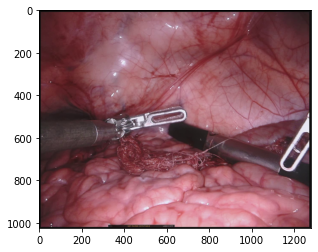

In [22]:
plt.imshow(frames["frame226.png"])

[0 1 2]
1


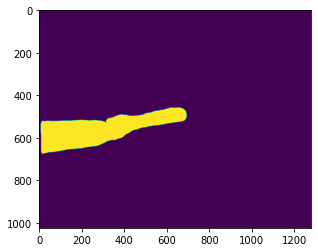

2


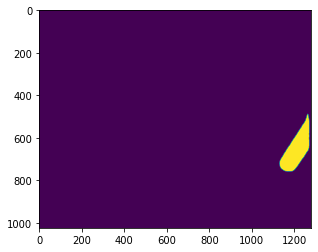

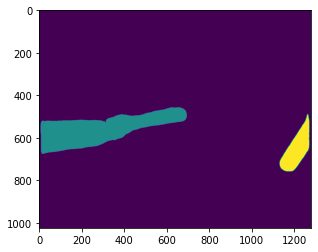

In [26]:
mask = torch_prob_to_numpy_mask(predictions["frame226.png"])
print(np.unique(mask))
for i in np.unique(mask):
    if i == 0:
        continue
    print(i)
    plt.imshow(np.where(mask == i, 1, 0))
    plt.show()
plt.imshow(mask)

[0 1 2]
1


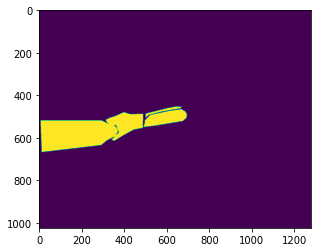

2


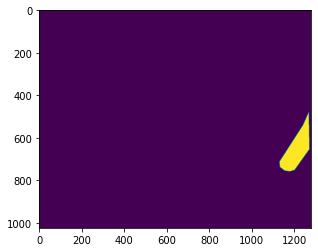

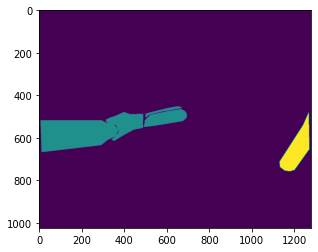

In [28]:
mask = io.imread(endo17_masks / "instrument_dataset_01_test" / "frame226.png")
mask = np.where(mask == 8, 0, mask)
print(np.unique(mask))
for i in np.unique(mask):
    if i == 0:
        continue
    print(i)
    plt.imshow(np.where(mask == i, 1, 0))
    plt.show()
plt.imshow(mask)